import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import  LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

load the dataset

In [2]:
housing = fetch_california_housing()

In [3]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
df["MedHouseVal"] = housing.target

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Data Understanding

In [7]:
df.shape

(20640, 9)

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [11]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Exploratory Data Analysis

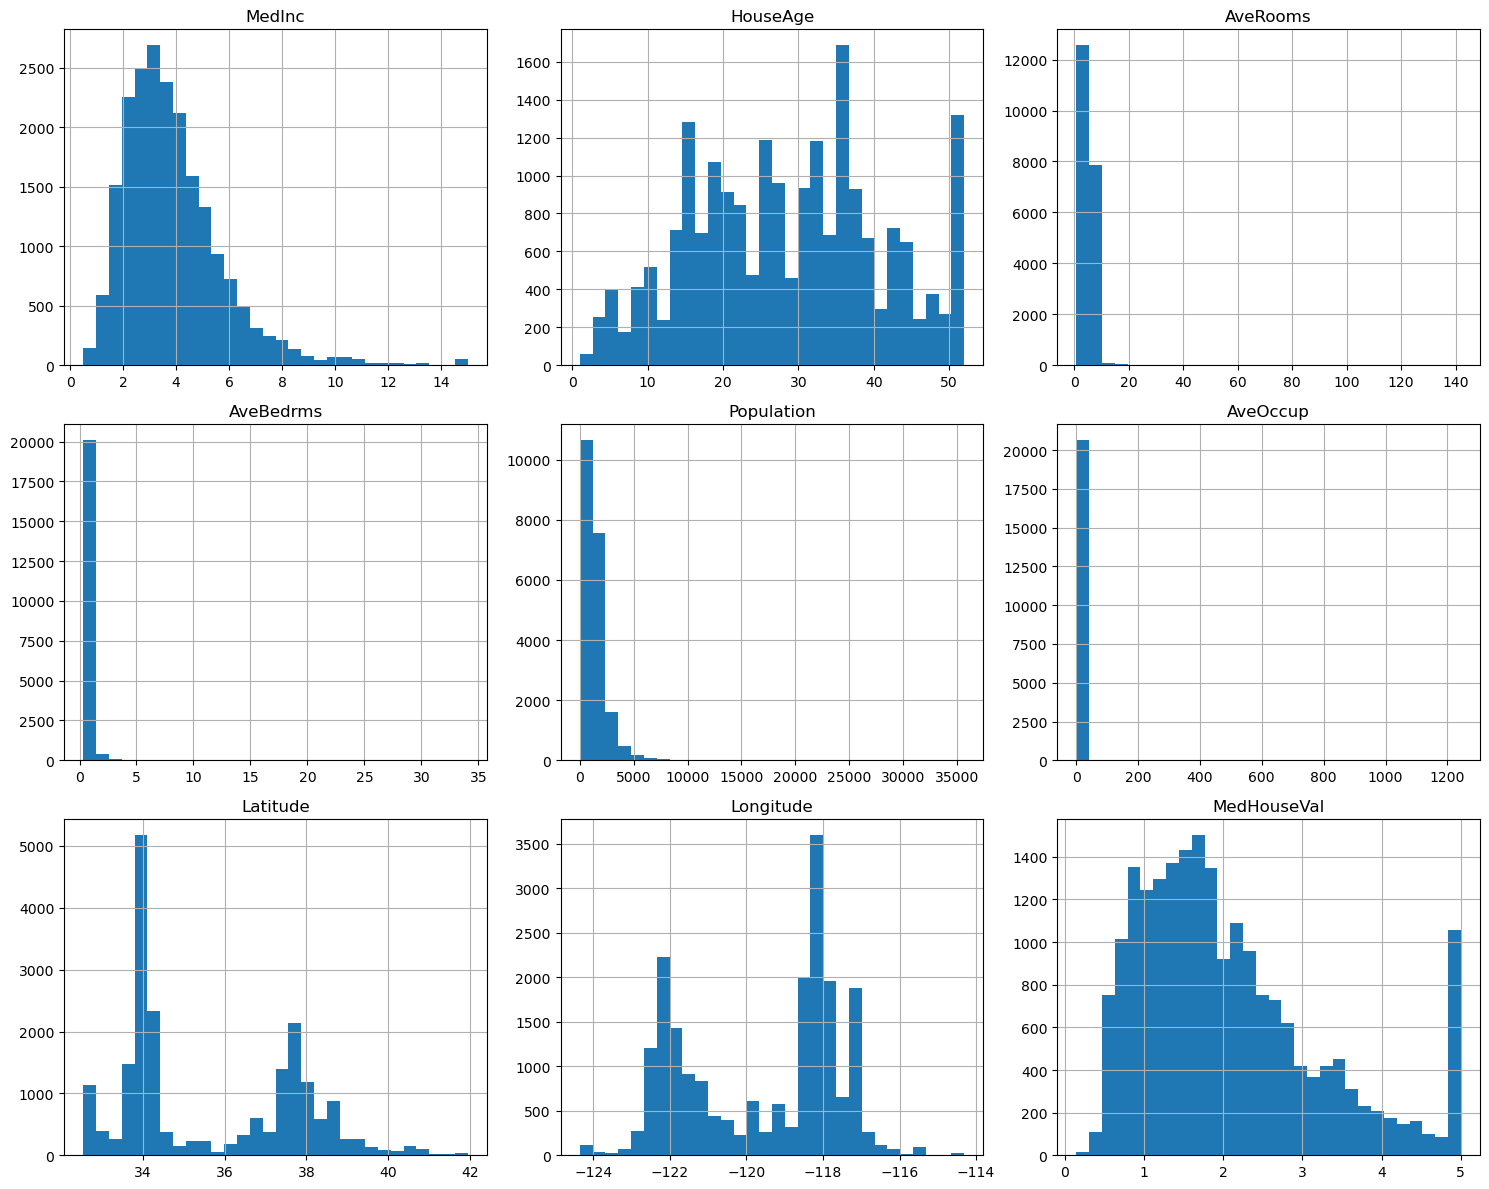

In [12]:
#histogram

df.hist(figsize=(15,12),bins=30)
plt.tight_layout()
plt.show()

Correlation Analysis

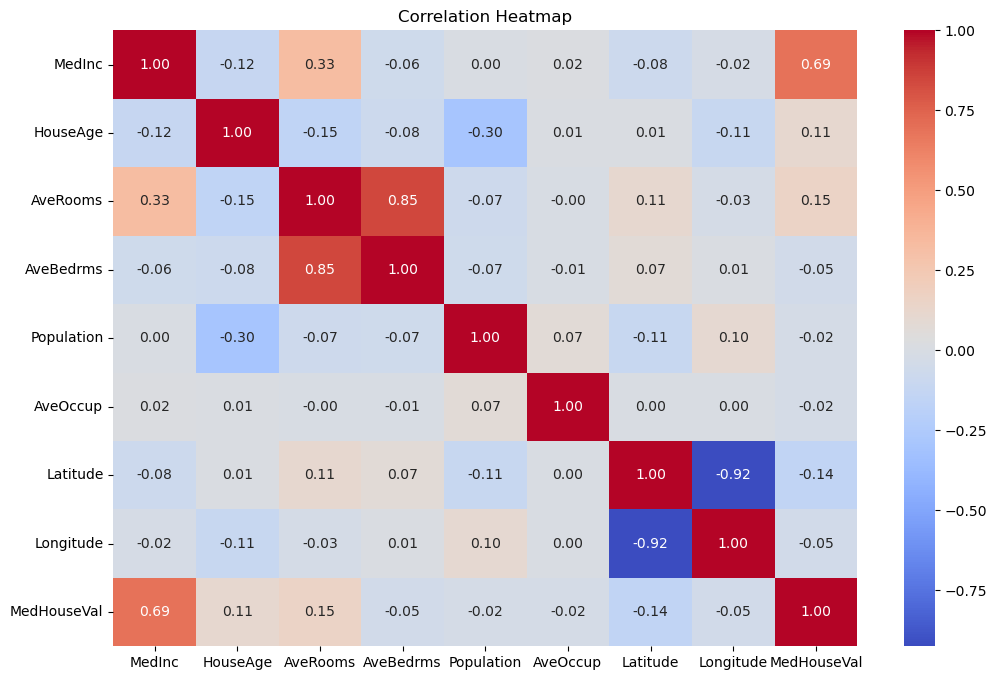

In [13]:
correlation = df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

Separate Features and Target

In [14]:
X = df.drop('MedHouseVal',axis=1)
y = df['MedHouseVal']

Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [16]:
#standardscaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.fit_transform(X_test)

In [17]:
X_train_scaled 

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]], shape=(16512, 8))

In [18]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [19]:
X_test_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-1.142376,-0.300740,-0.433677,-0.121865,-0.026548,0.520224,0.221941,0.255417
1,-0.690505,0.098724,-0.130503,0.158749,0.128764,-0.162932,-0.209477,0.029766
2,-0.186169,1.856363,-0.510634,0.146267,-0.100164,-0.915576,1.037884,-1.464546
3,1.013807,-0.939881,0.271824,-0.125278,0.254450,0.273237,-0.612759,0.400837
4,-0.055993,0.418295,0.031825,-0.112435,-0.321910,-0.274819,0.484544,-1.208808
...,...,...,...,...,...,...,...,...
4123,0.411772,-1.019774,0.571918,-0.049605,-0.063356,0.013409,-1.044178,1.153008
4124,-0.586693,-0.061061,0.260472,0.262408,0.205073,-0.356514,-0.106312,-0.657216
4125,2.870089,-0.300740,0.656181,-0.244957,0.146719,-0.099788,0.808107,-1.268982
4126,-0.555650,0.578080,-0.041164,-0.186052,-0.174678,-0.214947,0.554884,-0.120668


In [20]:
X_train_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551
...,...,...,...,...,...,...,...,...
16507,1.307215,0.507194,0.290620,-0.393391,-0.675847,-0.005588,-0.872016,0.808883
16508,-0.436266,0.348490,0.600411,0.398898,0.287195,0.069722,-0.759688,1.073144
16509,-0.496973,0.586545,-0.606759,-0.039216,0.289833,0.020306,-0.755007,0.599469
16510,0.965450,-1.079841,0.402175,-0.066265,0.308303,0.007076,0.906510,-1.185540


Model 1 — Linear Regression

In [21]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_model.fit(X_train,y_train)
y_pred_linear = linear_model.predict(X_test)

Evaluate Linear Regression

In [22]:
mse_linear = mean_squared_error(y_test,y_pred_linear)
mae_linear = mean_absolute_error(y_test,y_pred_linear)
r2_linear = r2_score(y_test,y_pred_linear)

print("Linear Regression")
print("MSE:", mse_linear)
print("MAE:", mae_linear)
print("R2:", r2_linear)

Linear Regression
MSE: 0.5558915986952444
MAE: 0.5332001304956566
R2: 0.5757877060324508


Model 2 — Decision Tree Regressor

In [23]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

Evaluate Decision Tree Regressor

In [24]:
mse_tree = mean_squared_error(y_test,y_pred_tree)
mae_tree = mean_absolute_error(y_test,y_pred_tree)
r2_tree = r2_score(y_test,y_pred_tree)

Model 3 — Random Forest Regressor

In [25]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

In [26]:
mse_forest = mean_squared_error(y_test, y_pred_forest)
mae_forest = mean_absolute_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print("Random Forest")
print("MSE:", mse_forest)
print("MAE:", mae_forest)
print("R2:", r2_forest)

Random Forest
MSE: 0.2553684927247781
MAE: 0.3275425684593025
R2: 0.8051230593157366


Model 4 — Gradient Boosting Regressor

In [27]:
gradient_model = GradientBoostingRegressor(
    random_state=42
)

gradient_model.fit(X_train, y_train)

y_pred_gradient = gradient_model.predict(X_test)

In [28]:
mse_gradient = mean_squared_error(y_test, y_pred_gradient)
mae_gradient = mean_absolute_error(y_test, y_pred_gradient)
r2_gradient = r2_score(y_test, y_pred_gradient)

print("Gradient Boosting")
print("MSE:", mse_gradient)
print("MAE:", mae_gradient)
print("R2:", r2_gradient)

Gradient Boosting
MSE: 0.2939973248643864
MAE: 0.3716425690425596
R2: 0.7756446042829697


Model 5 — Support Vector Regression

In [30]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

evaluate

In [32]:
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR")
print("MSE:", mse_svr)
print("MAE:", mae_svr)
print("R2:", r2_svr)

SVR
MSE: 0.35700403193386476
MAE: 0.39859907695205377
R2: 0.7275628923016775


Compare All The Models

In [33]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "MSE": [
        mse_linear,
        mse_tree,
        mse_forest,
        mse_gradient,
        mse_svr
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_forest,
        mae_gradient,
        mae_svr
    ],
    "R2": [
        r2_linear,
        r2_tree,
        r2_forest,
        r2_gradient,
        r2_svr
    ]
})

comparison

,Model,MSE,MAE,R2
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563


Identifying The Best Performing Model

In [34]:
best_model = comparison.loc[comparison["R2"].idxmax()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model    Random Forest
MSE           0.255368
MAE           0.327543
R2            0.805123
Name: 2, dtype: object


In [35]:
print("Lowest MSE:")
print(comparison.loc[comparison["MSE"].idxmin()])

print("\nLowest MAE:")
print(comparison.loc[comparison["MAE"].idxmin()])

Lowest MSE:
Model    Random Forest
MSE           0.255368
MAE           0.327543
R2            0.805123
Name: 2, dtype: object

Lowest MAE:
Model    Random Forest
MSE           0.255368
MAE           0.327543
R2            0.805123
Name: 2, dtype: object


Identify the worst-performing model

In [36]:
worst_model = comparison.loc[comparison["R2"].idxmin()]

print("Worst Performing Model:")
print(worst_model)

Worst Performing Model:
Model    Linear Regression
MSE               0.555892
MAE                 0.5332
R2                0.575788
Name: 0, dtype: object


In [37]:
print("Highest MSE:")
print(comparison.loc[comparison["MSE"].idxmax()])

print("\nHighest MAE:")
print(comparison.loc[comparison["MAE"].idxmax()])

Highest MSE:
Model    Linear Regression
MSE               0.555892
MAE                 0.5332
R2                0.575788
Name: 0, dtype: object

Highest MAE:
Model    Linear Regression
MSE               0.555892
MAE                 0.5332
R2                0.575788
Name: 0, dtype: object


Cross-validation

In [38]:
#Cross-validation for Linear Regression

In [39]:
cv_linear = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Linear Regression CV R2:")
print(cv_linear)

print("Mean CV R2:", cv_linear.mean())

Linear Regression CV R2:
[0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean CV R2: 0.5530311140279565


In [40]:
#Cross-validation for Decision Tree

In [41]:
cv_tree = cross_val_score(
    tree_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Decision Tree CV R2:", cv_tree)
print("Mean CV R2:", cv_tree.mean())

Decision Tree CV R2: [0.27093461 0.41372445 0.43912441 0.23566991 0.41875969]
Mean CV R2: 0.355642615410327


In [42]:
#Cross-validation for Random Forest

In [43]:
cv_forest = cross_val_score(
    forest_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Random Forest CV R2:", cv_forest)
print("Mean CV R2:", cv_forest.mean())

Random Forest CV R2: [0.51688816 0.70429935 0.74214734 0.63501894 0.68223973]
Mean CV R2: 0.6561187027256853


In [44]:
#Cross-validation for Gradient Boosting

In [45]:
cv_gradient = cross_val_score(
    gradient_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Gradient Boosting CV R2:", cv_gradient)
print("Mean CV R2:", cv_gradient.mean())

Gradient Boosting CV R2: [0.60241028 0.69877396 0.71802327 0.65023363 0.67973314]
Mean CV R2: 0.6698348552584348


In [46]:
#Cross-validation for SVR

In [47]:
cv_svr = cross_val_score(
    svr_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("SVR CV R2:", cv_svr)
print("Mean CV R2:", cv_svr.mean())

SVR CV R2: [0.74259473 0.6017722  0.68438388 0.60509452 0.70964174]
Mean CV R2: 0.6686974149204495


In [48]:
#Create a Cross-Validation Table

In [49]:
cv_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    
    "Mean CV R2": [
        cv_linear.mean(),
        cv_tree.mean(),
        cv_forest.mean(),
        cv_gradient.mean(),
        cv_svr.mean()
    ],
    
    "Std CV R2": [
        cv_linear.std(),
        cv_tree.std(),
        cv_forest.std(),
        cv_gradient.std(),
        cv_svr.std()
    ]
})

cv_results.sort_values(
    by="Mean CV R2",
    ascending=False
)

,Model,Mean CV R2,Std CV R2
3,Gradient Boosting,0.669835,0.040467
4,SVR,0.668697,0.056405
2,Random Forest,0.656119,0.077762
0,Linear Regression,0.553031,0.061692
1,Decision Tree,0.355643,0.084729


Hyperparameter Tuning

In [50]:
#Tune Decision Tree
tree_param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [51]:
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [52]:
#Tune Random Forest
forest_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [55]:
forest_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    forest_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

forest_grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [56]:
#Tune Gradient Boosting
gradient_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

In [57]:
gradient_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gradient_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gradient_grid.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [58]:
#Tune SVR
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

In [59]:
svr_param_grid = {
    "model__C": [1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1],
    "model__epsilon": [0.01, 0.1, 0.2]
}

Evaluate the Tuned Models

In [ ]:
best_tree = tree_grid.best_estimator_
best_forest = forest_grid.best_estimator_
best_gradient = gradient_grid.best_estimator_
best_svr = svr_grid.best_estimator_

In [ ]:
pred_tree_tuned = best_tree.predict(X_test)

pred_forest_tuned = best_forest.predict(X_test)

pred_gradient_tuned = best_gradient.predict(X_test)

pred_svr_tuned = best_svr.predict(X_test)

The Best Regression Model

In [61]:
# Sort test results by R2
final_results = comparison.sort_values(
    by="R2",
    ascending=False
)

print(final_results)

               Model       MSE       MAE        R2
2      Random Forest  0.255368  0.327543  0.805123
3  Gradient Boosting  0.293997  0.371643  0.775645
4                SVR  0.357004  0.398599  0.727563
1      Decision Tree  0.495235  0.454679  0.622076
0  Linear Regression  0.555892  0.533200  0.575788


In [62]:
cv_results.sort_values(
    by="Mean CV R2",
    ascending=False
)

,Model,Mean CV R2,Std CV R2
3,Gradient Boosting,0.669835,0.040467
4,SVR,0.668697,0.056405
2,Random Forest,0.656119,0.077762
0,Linear Regression,0.553031,0.061692
1,Decision Tree,0.355643,0.084729
